<a href="https://colab.research.google.com/github/Santosh-87/IMDB_Movie_Sentiment_Analysis/blob/main/IMDB_Movie_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**IMPORTING THE IMDB 50K MOVIE REVIEW DATASET FROM KAGGLE**

In [3]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# The file to be loaded from the kaggle data source
file_path = "IMDB Dataset.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "lakshmi25npathi/imdb-dataset-of-50k-movie-reviews",
  file_path,
)


Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.


In [4]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


**Performing Exploratory Data Analysis (EDA) of the IMDB 50K Movie Reviews Dataset**

In [5]:
df.shape

(50000, 2)

In [6]:
df['review'][0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [8]:
df.groupby(['sentiment'])[['sentiment']].count()

,sentiment
sentiment,
negative,25000
positive,25000


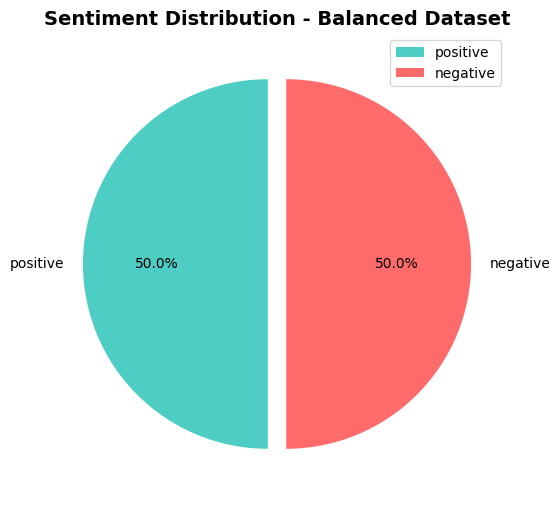

In [9]:
plt.figure(figsize=(8, 6))
sentiment_counts = df['sentiment'].value_counts()
plt.pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%',
        colors=['#4ecdc4', '#ff6b6b'], startangle=90, explode=[0.05, 0.05])
plt.title('Sentiment Distribution - Balanced Dataset', fontsize=14, fontweight='bold')
plt.legend(loc='best')
plt.show()

In [10]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [11]:
df['review_length'] = df['review'].apply(len)

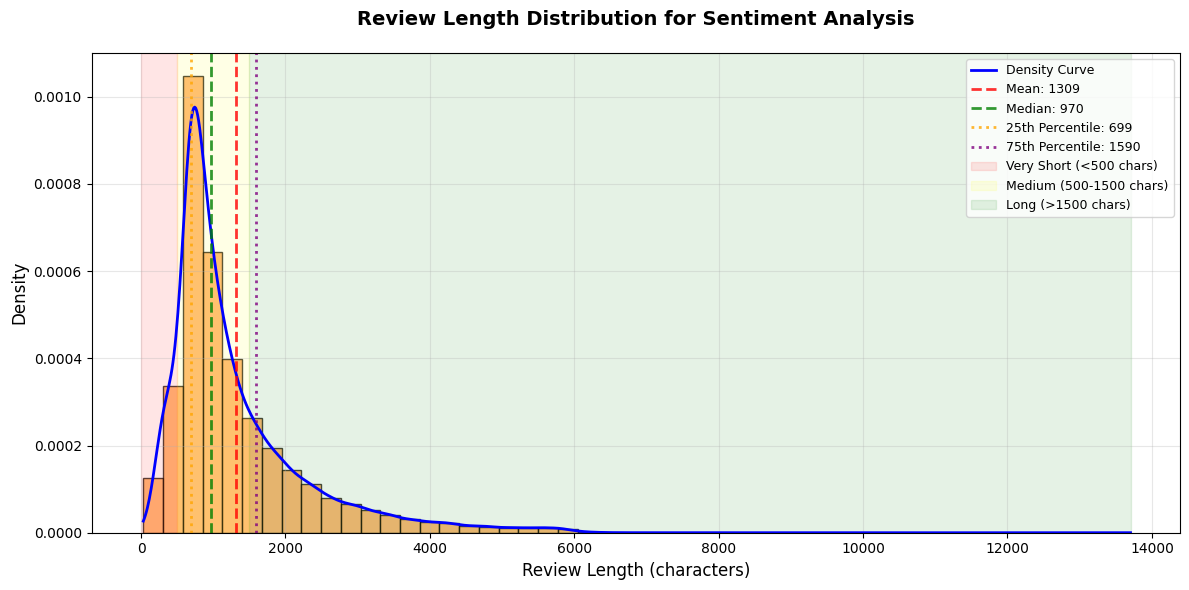

In [12]:
plt.figure(figsize=(12, 6))

# Create histogram with density curve
plt.hist(df['review_length'], bins=50,
         color='#ff9f43', edgecolor='black',
         alpha=0.7, density=True)

# Add kernel density estimate (smooth curve)
from scipy import stats
kde = stats.gaussian_kde(df['review_length'])
x_range = np.linspace(df['review_length'].min(), df['review_length'].max(), 1000)
plt.plot(x_range, kde(x_range), 'b-', linewidth=2, label='Density Curve')

# Add statistical lines (LEGEND ONLY - no text box)
stats_lines = [
    ('Mean', df['review_length'].mean(), 'red', '--'),
    ('Median', df['review_length'].median(), 'green', '--'),
    ('25th Percentile', df['review_length'].quantile(0.25), 'orange', ':'),
    ('75th Percentile', df['review_length'].quantile(0.75), 'purple', ':')
]

for name, value, color, style in stats_lines:
    plt.axvline(value, color=color, linestyle=style, linewidth=2,
                alpha=0.8, label=f'{name}: {value:.0f}')

# Highlight different regions
plt.axvspan(0, 500, alpha=0.1, color='red', label='Very Short (<500 chars)')
plt.axvspan(500, 1500, alpha=0.1, color='yellow', label='Medium (500-1500 chars)')
plt.axvspan(1500, df['review_length'].max(), alpha=0.1, color='green',
            label='Long (>1500 chars)')

# Labels and formatting
plt.xlabel('Review Length (characters)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Review Length Distribution for Sentiment Analysis',
          fontsize=14, fontweight='bold', pad=20)
plt.legend(loc='upper right', fontsize=9)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
def no_of_words(text):
  words = text.split()
  word_count = len(words)
  return word_count

In [14]:
df['word_count'] = df['review'].apply(no_of_words)

In [15]:
df.head(10)

,review,sentiment,review_length,word_count
0,One of the other reviewers has mentioned that ...,positive,1761,307
1,A wonderful little production. <br /><br />The...,positive,998,162
2,I thought this was a wonderful way to spend ti...,positive,926,166
3,Basically there's a family where a little boy ...,negative,748,138
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1317,230
5,"Probably my all-time favorite movie, a story o...",positive,656,119
6,I sure would like to see a resurrection of a u...,positive,726,150
7,"This show was an amazing, fresh & innovative i...",negative,934,174
8,Encouraged by the positive comments about this...,negative,681,130
9,If you like original gut wrenching laughter yo...,positive,176,33


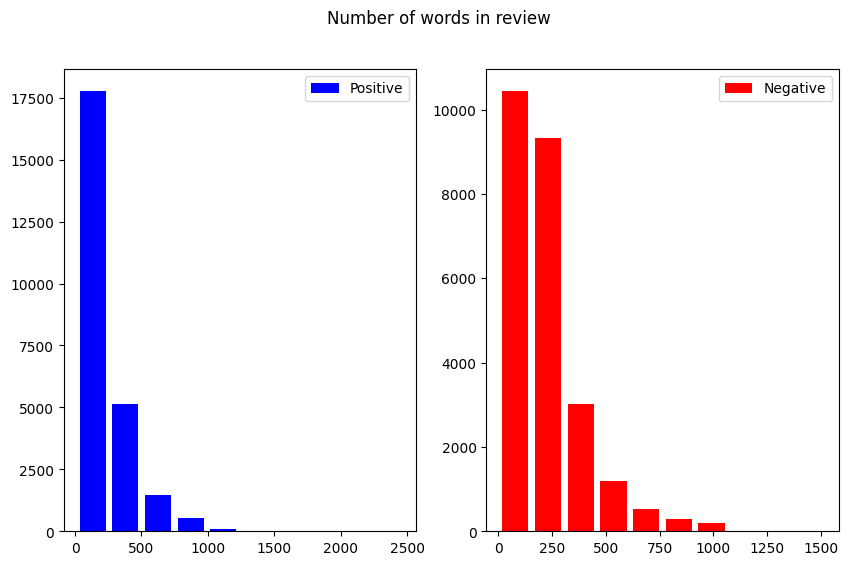

In [16]:
fig, ax = plt.subplots(1,2, figsize=(10,6))
ax[0].hist(df[df['sentiment'] == 'positive']['word_count'], label='Positive', color='blue', rwidth=0.8);
ax[1].hist(df[df['sentiment'] == 'negative']['word_count'], label='Negative', color='red', rwidth=0.8);

ax[0].legend(loc='upper right');
ax[1].legend(loc='upper right');

fig.suptitle("Number of words in review")
plt.show()

In [17]:
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

In [18]:
df.head()

,review,sentiment,review_length,word_count
0,One of the other reviewers has mentioned that ...,1,1761,307
1,A wonderful little production. <br /><br />The...,1,998,162
2,I thought this was a wonderful way to spend ti...,1,926,166
3,Basically there's a family where a little boy ...,0,748,138
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,1317,230


**TEXT PREPROCESSING**

In [19]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from bs4 import BeautifulSoup
import re


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [20]:
stop_words = set(stopwords.words('english'))
lemm = WordNetLemmatizer()

def clean_text(review):

    review = BeautifulSoup(review, "html.parser").get_text()
    review = review.lower()
    review = re.sub(r"http\S+|www\S+|https\S+", "", review)
    review = re.sub(r"@\w+|#", "", review)
    review = re.sub("[^a-zA-Z]", " ", review)

    tokens = word_tokenize(review)

    filtered = [lemm.lemmatize(w) for w in tokens if w not in stop_words]

    return " ".join(filtered)

In [21]:
df['clean_review'] = df['review'].apply(clean_text)

In [22]:
df['clean_review'][0]

'one reviewer mentioned watching oz episode hooked right exactly happened first thing struck oz brutality unflinching scene violence set right word go trust show faint hearted timid show pull punch regard drug sex violence hardcore classic use word called oz nickname given oswald maximum security state penitentary focus mainly emerald city experimental section prison cell glass front face inwards privacy high agenda em city home many aryan muslim gangsta latino christian italian irish scuffle death stare dodgy dealing shady agreement never far away would say main appeal show due fact go show dare forget pretty picture painted mainstream audience forget charm forget romance oz mess around first episode ever saw struck nasty surreal say ready watched developed taste oz got accustomed high level graphic violence violence injustice crooked guard sold nickel inmate kill order get away well mannered middle class inmate turned prison bitch due lack street skill prison experience watching oz m

In [23]:
df.sample(5)

,review,sentiment,review_length,word_count,clean_review
15925,This movie is so bad it's funny. It stars Scot...,0,1015,198,movie bad funny star scott backula coach impor...
9286,Anthony Perkins and Sophia Loren are absolutel...,0,1629,267,anthony perkins sophia loren absolutely gorgeo...
4397,"When I was younger, this movie always aired on...",1,724,135,younger movie always aired friday night summer...
608,I have recently seen this production on DVD. I...,1,2296,423,recently seen production dvd first time seen s...
47796,"This film is so incredibly bad, that I almost ...",0,1092,196,film incredibly bad almost felt sick watching ...


In [1]:
# !python -m nltk.downloader punkt punkt_tab stopwords wordnet
# import nltk
# nltk.data.path.append('/usr/share/nltk_data')

<frozen runpy>:128: RuntimeWarning: 'nltk.downloader' found in sys.modules after import of package 'nltk', but prior to execution of 'nltk.downloader'; this may result in unpredictable behaviour
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [24]:
print(df.clean_review)

0        one reviewer mentioned watching oz episode hoo...
1        wonderful little production filming technique ...
2        thought wonderful way spend time hot summer we...
3        basically family little boy jake think zombie ...
4        petter mattei love time money visually stunnin...
                               ...                        
49995    thought movie right good job creative original...
49996    bad plot bad dialogue bad acting idiotic direc...
49997    catholic taught parochial elementary school nu...
49998    going disagree previous comment side maltin on...
49999    one expects star trek movie high art fan expec...
Name: clean_review, Length: 50000, dtype: object


In [25]:
df['new_word_count'] = df['clean_review'].apply(no_of_words)
df.head()

,review,sentiment,review_length,word_count,clean_review,new_word_count
0,One of the other reviewers has mentioned that ...,1,1761,307,one reviewer mentioned watching oz episode hoo...,162
1,A wonderful little production. <br /><br />The...,1,998,162,wonderful little production filming technique ...,86
2,I thought this was a wonderful way to spend ti...,1,926,166,thought wonderful way spend time hot summer we...,84
3,Basically there's a family where a little boy ...,0,748,138,basically family little boy jake think zombie ...,64
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,1317,230,petter mattei love time money visually stunnin...,125


In [26]:
pos_reviews =  df[df.sentiment == 1]
pos_reviews.head()

,review,sentiment,review_length,word_count,clean_review,new_word_count
0,One of the other reviewers has mentioned that ...,1,1761,307,one reviewer mentioned watching oz episode hoo...,162
1,A wonderful little production. <br /><br />The...,1,998,162,wonderful little production filming technique ...,86
2,I thought this was a wonderful way to spend ti...,1,926,166,thought wonderful way spend time hot summer we...,84
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,1317,230,petter mattei love time money visually stunnin...,125
5,"Probably my all-time favorite movie, a story o...",1,656,119,probably time favorite movie story selflessnes...,54


In [27]:
neg_reviews =  df[df.sentiment == 0]
neg_reviews.head()

,review,sentiment,review_length,word_count,clean_review,new_word_count
3,Basically there's a family where a little boy ...,0,748,138,basically family little boy jake think zombie ...,64
7,"This show was an amazing, fresh & innovative i...",0,934,174,show amazing fresh innovative idea first aired...,78
8,Encouraged by the positive comments about this...,0,681,130,encouraged positive comment film looking forwa...,62
10,Phil the Alien is one of those quirky films wh...,0,578,96,phil alien one quirky film humour based around...,50
11,I saw this movie when I was about 12 when it c...,0,937,180,saw movie came recall scariest scene big bird ...,82


In [28]:
from collections import Counter
count = Counter()
for text in pos_reviews['clean_review'].values:
    for word in text.split():
        count[word] +=1
count.most_common(20)

[('film', 49690),
 ('movie', 44835),
 ('one', 28280),
 ('like', 18193),
 ('time', 16309),
 ('good', 15089),
 ('story', 14181),
 ('character', 14020),
 ('great', 13009),
 ('see', 12926),
 ('well', 12827),
 ('make', 11242),
 ('get', 11194),
 ('also', 10792),
 ('really', 10736),
 ('would', 10594),
 ('scene', 10054),
 ('life', 9897),
 ('show', 9664),
 ('even', 9613)]

In [29]:
pos_words = pd.DataFrame(count.most_common(20))
pos_words.columns = ['word', 'count']
pos_words.head()

,word,count
0,film,49690
1,movie,44835
2,one,28280
3,like,18193
4,time,16309


In [30]:
import plotly.express as px

In [31]:
px.bar(pos_words, x='count', y='word', title='Common words in positive reviews', color = 'word')

In [32]:
count = Counter()
for text in neg_reviews['clean_review'].values:
    for word in text.split():
        count[word] +=1
count.most_common(20)

[('movie', 58403),
 ('film', 43733),
 ('one', 27152),
 ('like', 22927),
 ('even', 15244),
 ('time', 15146),
 ('good', 14763),
 ('bad', 14713),
 ('character', 14324),
 ('would', 14005),
 ('get', 13456),
 ('make', 12957),
 ('really', 12354),
 ('scene', 11378),
 ('see', 11138),
 ('story', 11082),
 ('much', 10115),
 ('people', 9536),
 ('thing', 9470),
 ('could', 9300)]

In [33]:
neg_words = pd.DataFrame(count.most_common(20))
neg_words.columns = ['word', 'count']
neg_words.head()

,word,count
0,movie,58403
1,film,43733
2,one,27152
3,like,22927
4,even,15244


In [34]:
px.bar(neg_words, x='count', y='word', title='Common words in negative reviews', color = 'word')

In [35]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [36]:
def generate_word_cloud(text, title="Word Cloud"):
    """
    Generate and display a word cloud
    """
    # Create word cloud
    wordcloud = WordCloud(
        width=1500,
        height=1000,
        max_words=150,
        random_state=42,
        collocations=False,
        background_color="white"
    ).generate(text)

    # Display
    plt.figure(figsize=(14, 8))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud: {title}", fontsize=30, pad=20)
    plt.show()

In [37]:
# Join all positive reviews
positive_text = " ".join(pos_reviews['clean_review'].values)

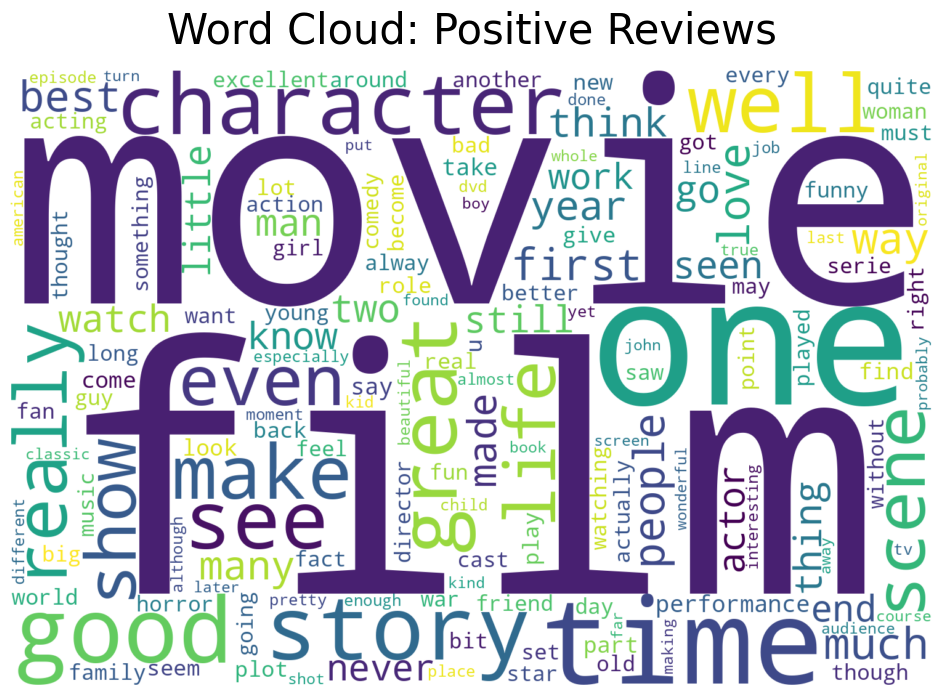

In [38]:
# Generate and display positive reviews word cloud
generate_word_cloud(positive_text, "Positive Reviews")

In [39]:
# Join all negative reviews
negative_text = " ".join(neg_reviews['clean_review'].values)

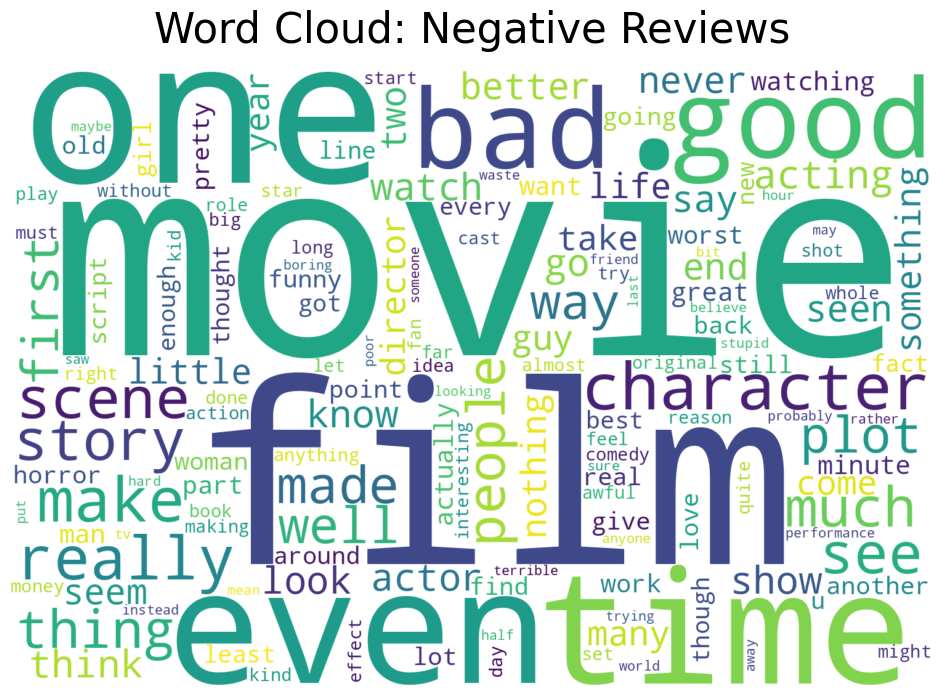

In [40]:
# Generate and display negative reviews word cloud
generate_word_cloud(negative_text, "Negative Reviews")

**Traditional Machine Learning Approach with Multinomial Naive Bayes Implementation**

In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

**TF-IDF VECTORIZER**

In [42]:
tfidf = TfidfVectorizer()

In [43]:
tfidf_unibi = TfidfVectorizer(
    ngram_range=(1, 2),   # unigrams + bigrams
    max_features=5000
)
tfidf_bigram = TfidfVectorizer(
    ngram_range=(2, 2),   # bigrams only
    max_features=5000
)

In [44]:
X = df["clean_review"]
Y = df['sentiment']

In [45]:
X

,clean_review
0,one reviewer mentioned watching oz episode hoo...
1,wonderful little production filming technique ...
2,thought wonderful way spend time hot summer we...
3,basically family little boy jake think zombie ...
4,petter mattei love time money visually stunnin...
...,...
49995,thought movie right good job creative original...
49996,bad plot bad dialogue bad acting idiotic direc...
49997,catholic taught parochial elementary school nu...
49998,going disagree previous comment side maltin on...


In [46]:
Y

,sentiment
0,1
1,1
2,1
3,0
4,1
...,...
49995,1
49996,0
49997,0
49998,0


In [47]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=df["sentiment"]
)

X_train_text.shape, X_test_text.shape

((40000,), (10000,))

In [48]:
X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)


In [49]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize


In [50]:
def display_confusion_matrix(y_true, y_pred, title=""):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')
    plt.title(f"Confusion Matrix for {title}")
    plt.show()


def display_ROC(y_test, y_prob, title=""):
    plt.figure(figsize=(8, 6))

    # Positive class = 1
    fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0, 1], [0, 1], linestyle='--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve for {title}")
    plt.legend()
    plt.show()

def display_precision_recall_curve(y_test, y_prob, title=""):
    precision, recall, _ = precision_recall_curve(y_test, y_prob[:, 1])
    avg_precision = average_precision_score(y_test, y_prob[:, 1])

    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, label=f"AP = {avg_precision:.2f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curve for {title}")
    plt.legend()
    plt.show()




In [51]:
mnb = MultinomialNB()
mnb.fit(X_train, y_train)
y_pred_nb = mnb.predict(X_test)
y_prob_nb = mnb.predict_proba(X_test)
mnb_acc = accuracy_score(y_pred_nb, y_test)
print(f"Test accuracy of Default Multinomial Naive Bayes model: {mnb_acc * 100:.2f}%")
print(confusion_matrix(y_test, y_pred_nb))
print("\n")
print(classification_report(y_test, y_pred_nb))

Test accuracy of Default Multinomial Naive Bayes model: 86.76%
[[4402  598]
 [ 726 4274]]


              precision    recall  f1-score   support

           0       0.86      0.88      0.87      5000
           1       0.88      0.85      0.87      5000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



In [52]:
print(confusion_matrix(y_test, y_pred_nb))
print("\n")
print(classification_report(y_test, y_pred_nb))


[[4402  598]
 [ 726 4274]]


              precision    recall  f1-score   support

           0       0.86      0.88      0.87      5000
           1       0.88      0.85      0.87      5000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



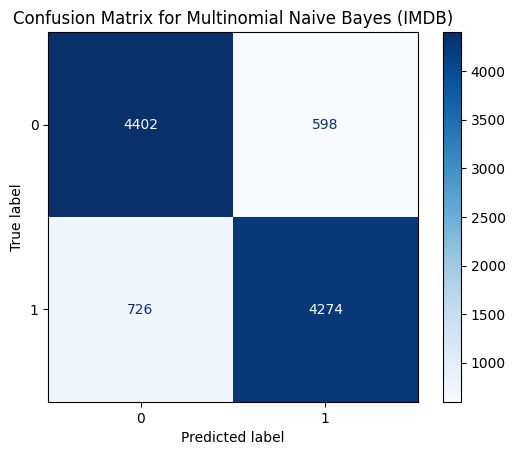

In [53]:
# Confusion Matrix
display_confusion_matrix(
    y_test,
    y_pred_nb,
    title="Multinomial Naive Bayes (IMDB)"
)


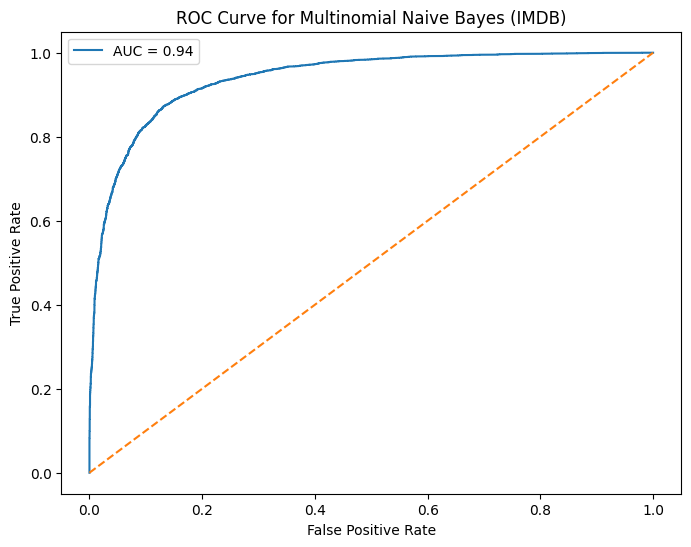

In [54]:
# ROC Curve
display_ROC(
    y_test,
    y_prob_nb,
    title="Multinomial Naive Bayes (IMDB)"
)

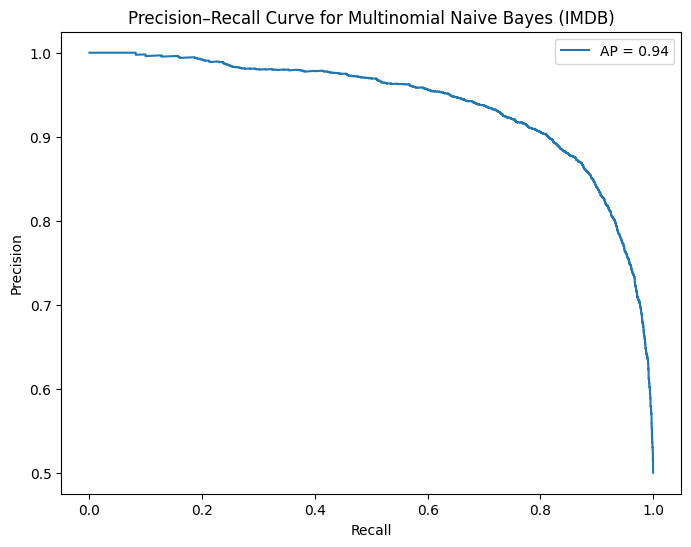

In [55]:
# Precision Recall Curve
display_precision_recall_curve(
    y_test,
    y_prob_nb,
    title="Multinomial Naive Bayes (IMDB)"
)


In [107]:
def predict_sentiment_nb_tfidf(text):
    text_vector = tfidf.transform([text])
    pred =mnb.predict(text_vector)[0]
    return "Positive" if pred == 1 else "Negative"

sample_reviews = [
    "This movie was very enjoyable and well made",
    "The story was boring and the acting was poor."
]

for review in sample_reviews:
    sentiment = predict_sentiment_nb_tfidf(review)
    print(f"Review: {review}")
    print(f"Predicted Sentiment: {sentiment}")
    print()

Review: This movie was very enjoyable and well made
Predicted Sentiment: Positive

Review: The story was boring and the acting was poor.
Predicted Sentiment: Negative



In [58]:
X_train_unibi = tfidf_unibi.fit_transform(X_train_text)
X_test_unibi = tfidf_unibi.transform(X_test_text)

In [59]:
mnb_unibi = MultinomialNB()
mnb_unibi.fit(X_train_unibi, y_train)



MultinomialNB()

In [60]:
y_pred_unibi = mnb_unibi.predict(X_test_unibi)
y_prob_unibi = mnb_unibi.predict_proba(X_test_unibi)



In [61]:
accuracy_unibi = accuracy_score(y_test, y_pred_unibi)
print(f"MNB with Unigrams+Bigrams (1,2) Accuracy: {accuracy_unibi * 100:.2f}%")
print(confusion_matrix(y_test, y_pred_unibi))
print(classification_report(y_test, y_pred_unibi))

MNB with Unigrams+Bigrams (1,2) Accuracy: 86.04%
[[4218  782]
 [ 614 4386]]
              precision    recall  f1-score   support

           0       0.87      0.84      0.86      5000
           1       0.85      0.88      0.86      5000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



In [62]:
print(classification_report(y_test, y_pred_unibi))

              precision    recall  f1-score   support

           0       0.87      0.84      0.86      5000
           1       0.85      0.88      0.86      5000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



In [63]:
X_train_bigram = tfidf_bigram.fit_transform(X_train_text)
X_test_bigram = tfidf_bigram.transform(X_test_text)


In [64]:
mnb_bigram = MultinomialNB()
mnb_bigram.fit(X_train_bigram, y_train)


MultinomialNB()

In [65]:
y_pred_bigram = mnb_bigram.predict(X_test_bigram)
y_prob_bigram = mnb_bigram.predict_proba(X_test_bigram)


accuracy_bigram = accuracy_score(y_test, y_pred_bigram)
print(f"MNB with Bigrams(2,2) Accuracy: {accuracy_bigram * 100:.2f}%")
print(confusion_matrix(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_bigram))

MNB with Bigrams(2,2) Accuracy: 81.68%
[[4402  598]
 [ 726 4274]]
              precision    recall  f1-score   support

           0       0.83      0.80      0.81      5000
           1       0.80      0.84      0.82      5000

    accuracy                           0.82     10000
   macro avg       0.82      0.82      0.82     10000
weighted avg       0.82      0.82      0.82     10000



In [66]:
print(classification_report(y_test, y_pred_bigram))

              precision    recall  f1-score   support

           0       0.83      0.80      0.81      5000
           1       0.80      0.84      0.82      5000

    accuracy                           0.82     10000
   macro avg       0.82      0.82      0.82     10000
weighted avg       0.82      0.82      0.82     10000



In [101]:
print("\n" + "="*70)
print("MULTINOMIAL NAIVE BAYES TF-IDF COMPARISON SUMMARY")
print("="*70)
print(f"Default Multinomial Naive Bayes Accuracy: {mnb_acc * 100:.2f}%")
print(f"Multinomial Naive Bayes Unigrams+Bigrams (1,2) Accuracy: {accuracy_unibi * 100:.2f}%")
print(f"Multinomial Naive Bayes Bigrams Only (2,2) Accuracy: {accuracy_bigram * 100:.2f}%")



MULTINOMIAL NAIVE BAYES TF-IDF COMPARISON SUMMARY
Default Multinomial Naive Bayes Accuracy: 86.76%
Multinomial Naive Bayes Unigrams+Bigrams (1,2) Accuracy: 86.04%
Multinomial Naive Bayes Bigrams Only (2,2) Accuracy: 81.68%


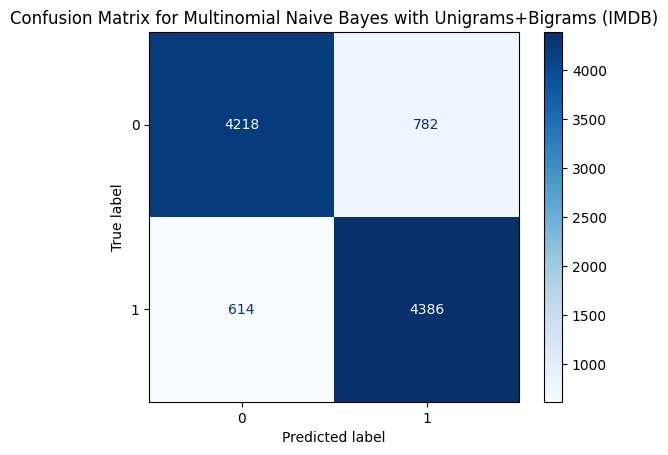

In [68]:
# Confusion Matrix for Unigrams+Bigrams
display_confusion_matrix(
    y_test,
    y_pred_unibi,
    title="Multinomial Naive Bayes with Unigrams+Bigrams (IMDB)"
)

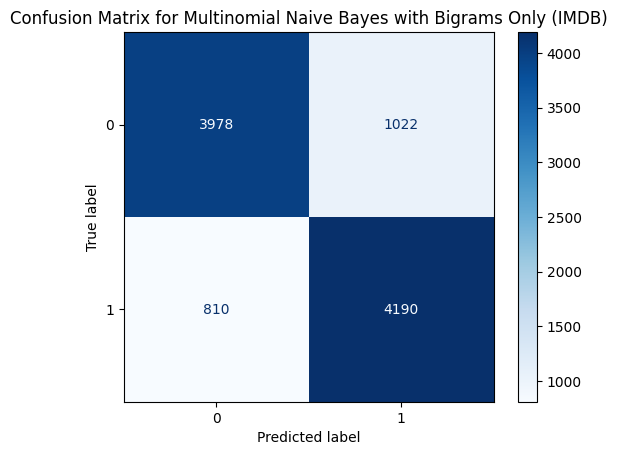

In [69]:
# 2. Confusion Matrix for Bigrams Only
display_confusion_matrix(
    y_test,
    y_pred_bigram,
    title="Multinomial Naive Bayes with Bigrams Only (IMDB)"
)

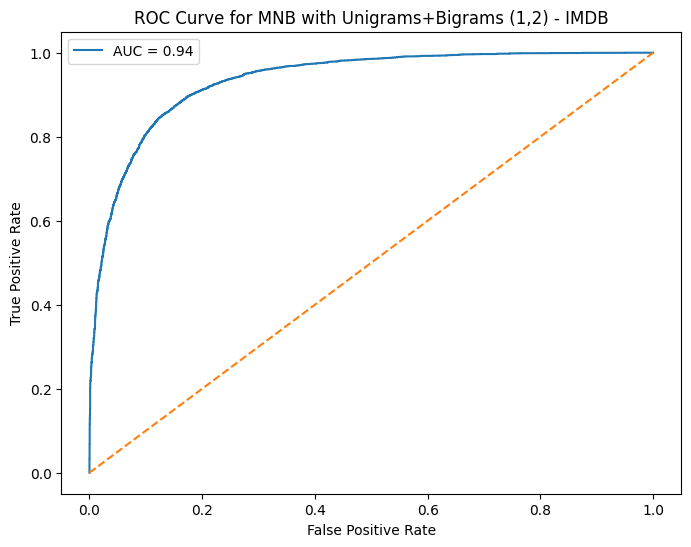

In [70]:

display_ROC(
    y_test,
    y_prob_unibi,
    title="MNB with Unigrams+Bigrams (1,2) - IMDB"
)

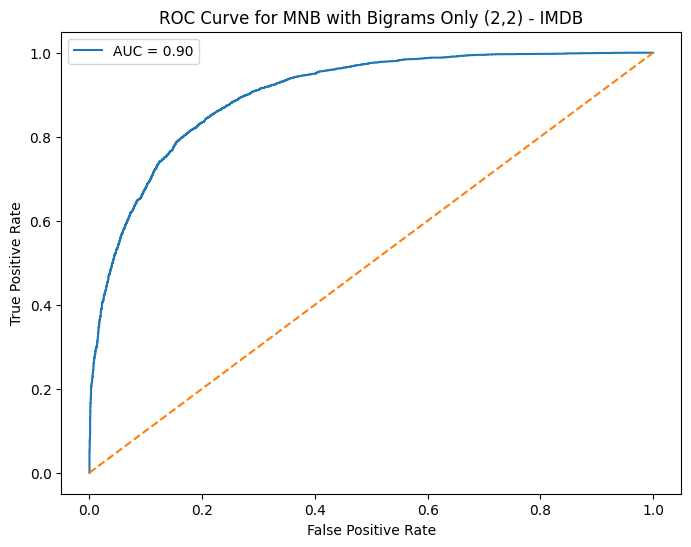

In [71]:
display_ROC(
    y_test,
    y_prob_bigram,
    title="MNB with Bigrams Only (2,2) - IMDB"
)

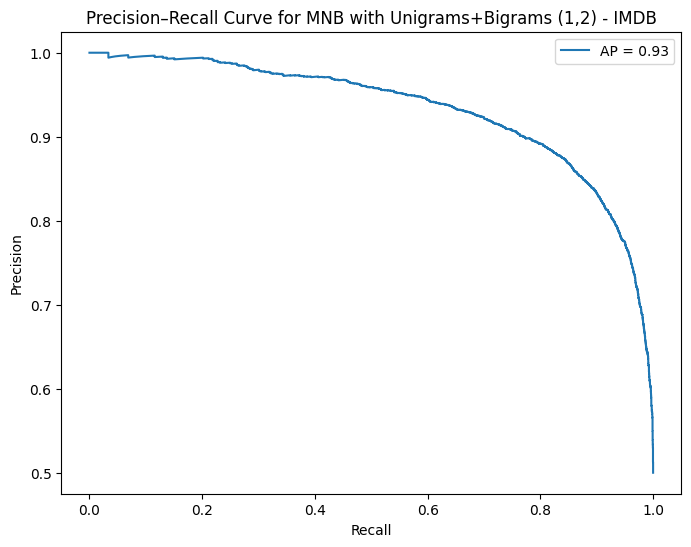

In [72]:
display_precision_recall_curve(
    y_test,
    y_prob_unibi,
    title="MNB with Unigrams+Bigrams (1,2) - IMDB"
)

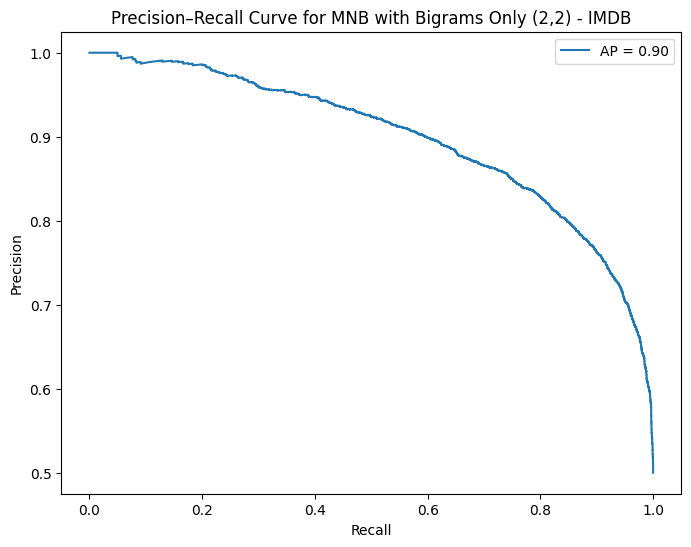

In [73]:
display_precision_recall_curve(
    y_test,
    y_prob_bigram,
    title="MNB with Bigrams Only (2,2) - IMDB"
)

**COUNT VECTORIZER**

In [74]:
from sklearn.feature_extraction.text import CountVectorizer

In [75]:
cv_uni = CountVectorizer()

X_train_cv = cv_uni.fit_transform(X_train_text)
X_test_cv = cv_uni.transform(X_test_text)

In [76]:
mnb_cv = MultinomialNB()
mnb_cv.fit(X_train_cv, y_train)

MultinomialNB()

In [77]:
y_pred_cv = mnb_cv.predict(X_test_cv)
y_prob_cv = mnb_cv.predict_proba(X_test_cv)

In [78]:
accuracy_cv = accuracy_score(y_test, y_pred_cv)
print(f"MNB with Count Vectorizer Accuracy: {accuracy_cv * 100:.2f}%")
print(confusion_matrix(y_test, y_pred_cv))
print(classification_report(y_test, y_pred_cv))

MNB with Count Vectorizer Accuracy: 85.97%
[[4407  593]
 [ 810 4190]]
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      5000
           1       0.88      0.84      0.86      5000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



In [79]:
print(classification_report(y_test, y_pred_cv))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      5000
           1       0.88      0.84      0.86      5000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



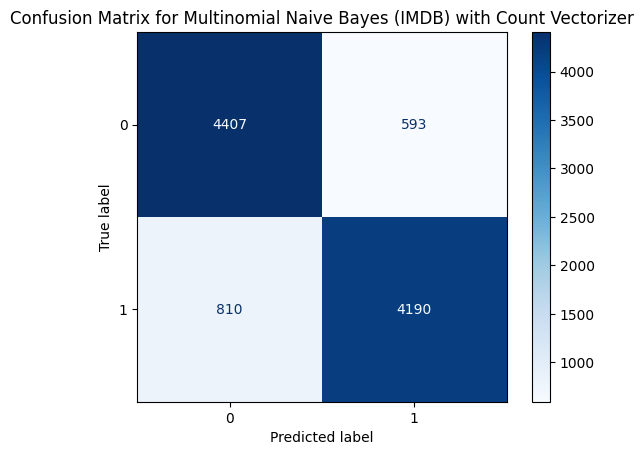

In [80]:
# Confusion Matrix
display_confusion_matrix(
    y_test,
    y_pred_cv,
    title="Multinomial Naive Bayes (IMDB) with Count Vectorizer"
)

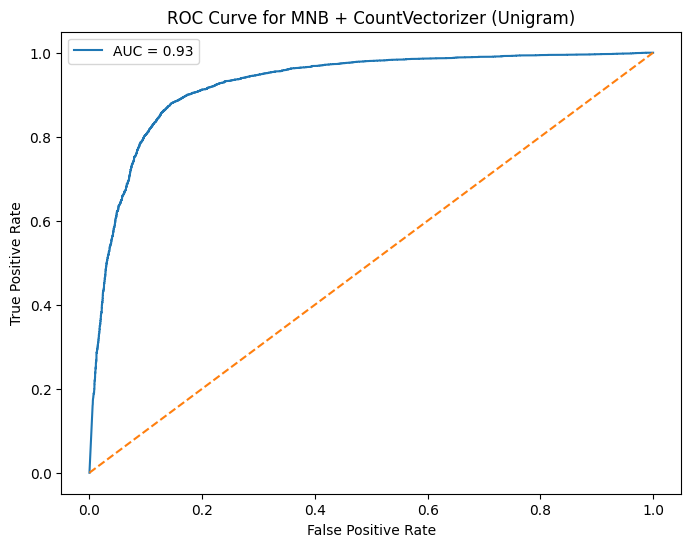

In [81]:
# ROC Curve
display_ROC(
    y_test,
    y_prob_cv,
    title="MNB + CountVectorizer (Unigram)"
)

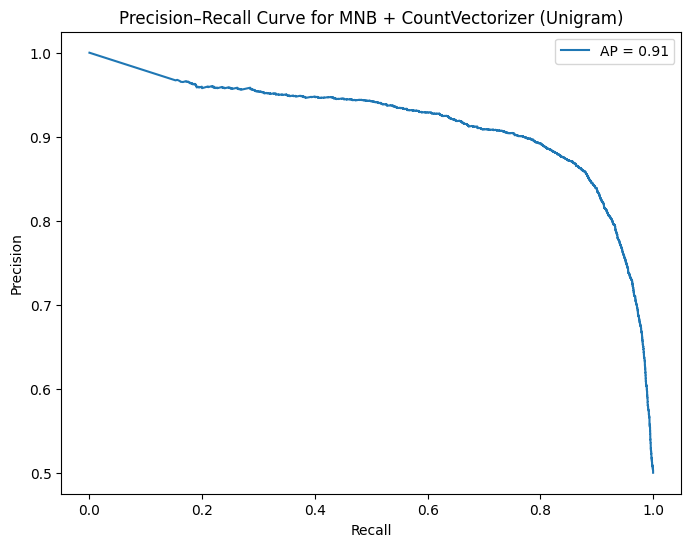

In [82]:
# Precision-Recall Curve
display_precision_recall_curve(
    y_test,
    y_prob_cv,
    title="MNB + CountVectorizer (Unigram)"
)

In [83]:
cv_12 = CountVectorizer(ngram_range=(1, 2))

X_train_cv_12 = cv_12.fit_transform(X_train_text)
X_test_cv_12 = cv_12.transform(X_test_text)

mnb_cv_12 = MultinomialNB()
mnb_cv_12.fit(X_train_cv_12, y_train)

y_pred_cv_12 = mnb_cv_12.predict(X_test_cv_12)
y_prob_cv_12 = mnb_cv_12.predict_proba(X_test_cv_12)

accuracy_cv_12=accuracy_score(y_test, y_pred_cv_12)
print(f"CountVectorizer (1,2) Accuracy: {accuracy_cv_12 * 100:.2f}%")
print(confusion_matrix(y_test, y_pred_cv_12))
print(classification_report(y_test, y_pred_cv_12))

CountVectorizer (1,2) Accuracy: 88.42%
[[4466  534]
 [ 624 4376]]
              precision    recall  f1-score   support

           0       0.88      0.89      0.89      5000
           1       0.89      0.88      0.88      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



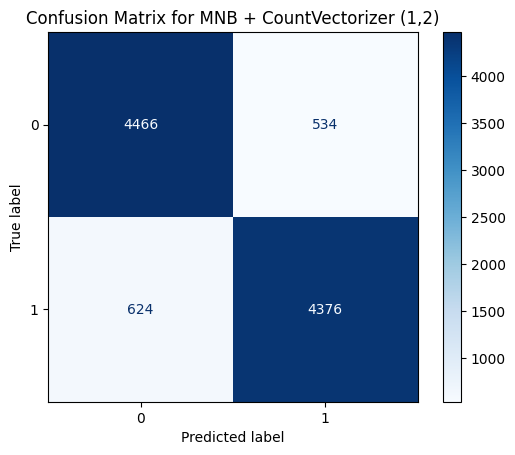

In [84]:
# Confusion Matrix
display_confusion_matrix(
    y_test,
    y_pred_cv_12,
    title="MNB + CountVectorizer (1,2)"
)

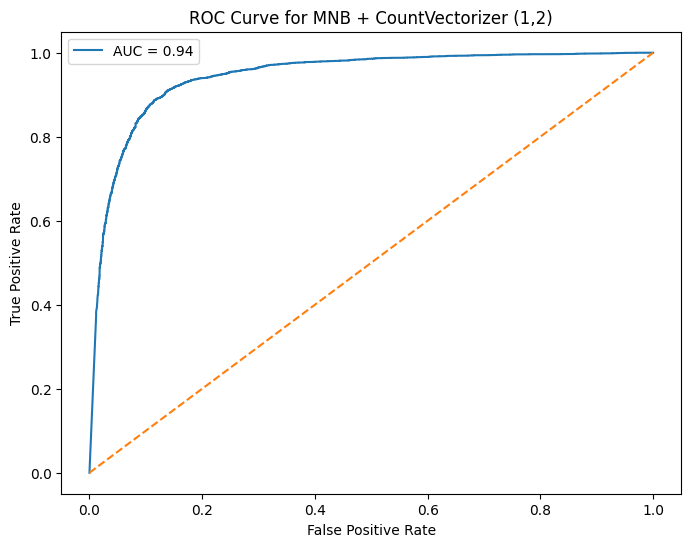

In [85]:
# ROC Curve
display_ROC(
    y_test,
    y_prob_cv_12,
    title="MNB + CountVectorizer (1,2)"
)

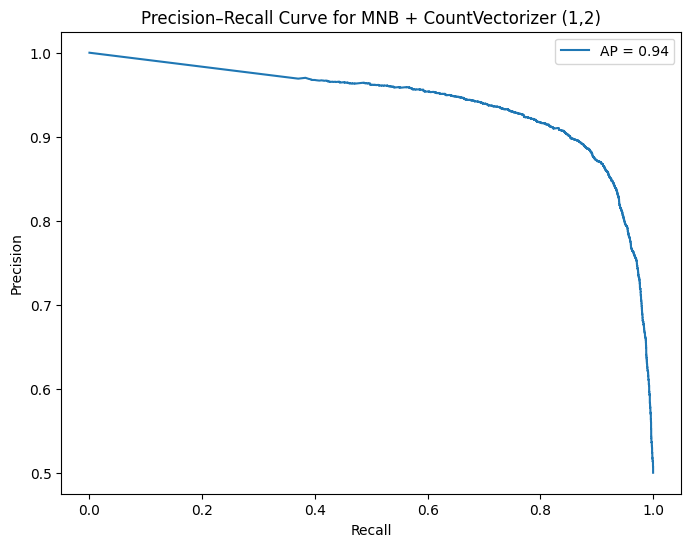

In [86]:
# Precision-Recall Curve
display_precision_recall_curve(
    y_test,
    y_prob_cv_12,
    title="MNB + CountVectorizer (1,2)"
)

In [87]:
cv_22 = CountVectorizer(ngram_range=(2, 2))

X_train_cv_22 = cv_22.fit_transform(X_train_text)
X_test_cv_22 = cv_22.transform(X_test_text)

mnb_cv_22 = MultinomialNB()
mnb_cv_22.fit(X_train_cv_22, y_train)

y_pred_cv_22 = mnb_cv_22.predict(X_test_cv_22)
y_prob_cv_22 = mnb_cv_22.predict_proba(X_test_cv_22)

accuracy_cv_22=accuracy_score(y_test, y_pred_cv_22)
print(f"CountVectorizer (2,2) Accuracy: {accuracy_cv_22 * 100:.2f}%")
print(confusion_matrix(y_test, y_pred_cv_22))
print(classification_report(y_test, y_pred_cv_22))

CountVectorizer (2,2) Accuracy: 87.83%
[[4475  525]
 [ 692 4308]]
              precision    recall  f1-score   support

           0       0.87      0.90      0.88      5000
           1       0.89      0.86      0.88      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [88]:
print(classification_report(y_test, y_pred_cv_22))

              precision    recall  f1-score   support

           0       0.87      0.90      0.88      5000
           1       0.89      0.86      0.88      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



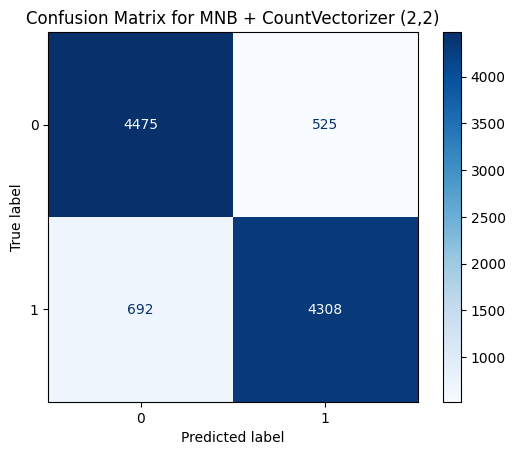

In [89]:
# Confusion Matrix
display_confusion_matrix(
    y_test,
    y_pred_cv_22,
    title="MNB + CountVectorizer (2,2)"
)

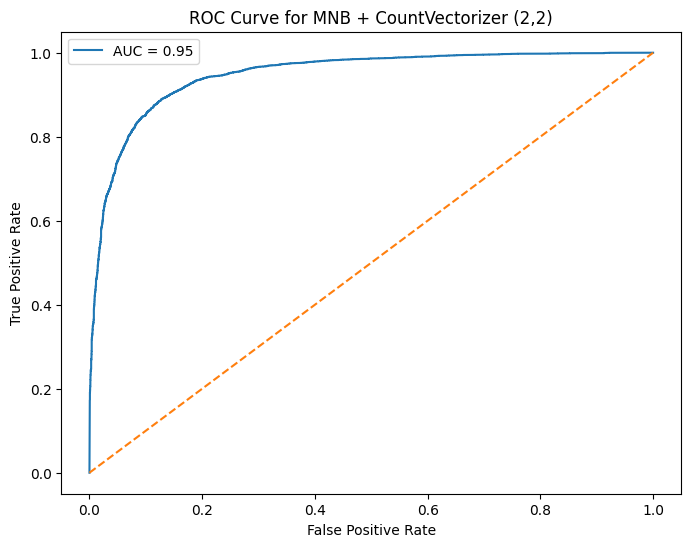

In [90]:
# ROC Curve
display_ROC(
    y_test,
    y_prob_cv_22,
    title="MNB + CountVectorizer (2,2)"
)

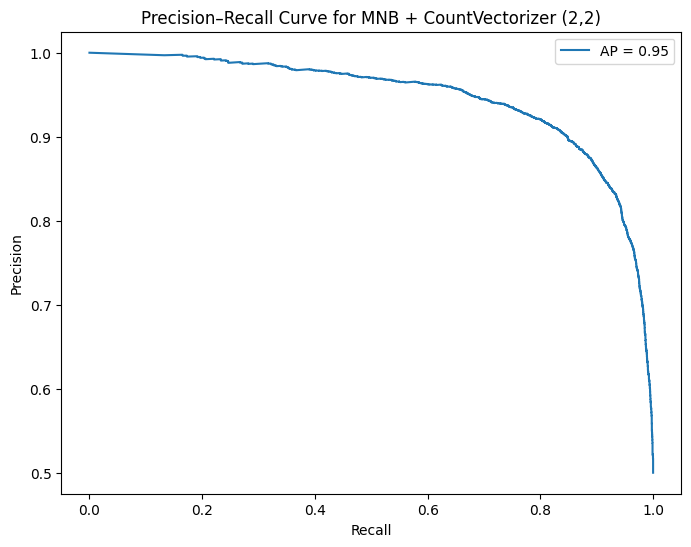

In [91]:
# Precision-Recall Curve
display_precision_recall_curve(
    y_test,
    y_prob_cv_22,
    title="MNB + CountVectorizer (2,2)"
)

In [102]:
print("\n" + "="*70)
print("MULTINOMIAL NAIVE BAYES COUNTVECTORIZER COMPARISON SUMMARY")
print("="*70)
print(f"Default Multinomial Naive Bayes CountVectorizer Accuracy: {accuracy_cv * 100:.2f}%")
print(f"Multinomial Naive Bayes CountVectorizer Unigrams+Bigrams (1,2) Accuracy: {accuracy_cv_12 * 100:.2f}%")
print(f"Multinomial Naive Bayes CountVectorizer Bigrams Only (2,2) Accuracy: {accuracy_cv_22 * 100:.2f}%")



MULTINOMIAL NAIVE BAYES COUNTVECTORIZER COMPARISON SUMMARY
Default Multinomial Naive Bayes CountVectorizer Accuracy: 85.97%
Multinomial Naive Bayes CountVectorizer Unigrams+Bigrams (1,2) Accuracy: 88.42%
Multinomial Naive Bayes CountVectorizer Bigrams Only (2,2) Accuracy: 87.83%


In [108]:
def predict_sentiment_nb_countvectorizer(text):

    text_vector = cv_12.transform([text])
    pred = mnb_cv_12.predict(text_vector)[0]
    return "Positive" if pred == 1 else "Negative"

sample_reviews = [
    "This movie was very enjoyable and well made",
    "The story was boring and the acting was poor."
]

for review in sample_reviews:
    sentiment = predict_sentiment_nb_countvectorizer(review)
    print(f"Review: {review}")
    print(f"Predicted Sentiment: {sentiment}")

Review: This movie was very enjoyable and well made
Predicted Sentiment: Positive
Review: The story was boring and the acting was poor.
Predicted Sentiment: Negative


**HYPERPARAMETER TUNING THE TF-IDF MULTINOMIAL NAIVE BAYES MODEL**

In [92]:
from sklearn.model_selection import GridSearchCV

In [93]:
param_grid = {
    'alpha': [0.01, 0.1, 0.5, 1.0],
    'fit_prior': [True, False]
}

In [94]:
grid_search = GridSearchCV(
    estimator=mnb,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


GridSearchCV(cv=5, estimator=MultinomialNB(), n_jobs=-1,
             param_grid={'alpha': [0.01, 0.1, 0.5, 1.0],
                         'fit_prior': [True, False]},
             scoring='accuracy', verbose=2)

In [95]:
best_mnb = grid_search.best_estimator_

print("Best alpha:", grid_search.best_params_['alpha'])

Best alpha: 0.5


In [96]:
y_pred_mnb_tuned = best_mnb.predict(X_test)
y_prob_mnb_tuned = best_mnb.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred_mnb_tuned)
print(f"Tuned MNB Accuracy: {accuracy * 100:.2f}%")

print(classification_report(y_test, y_pred_mnb_tuned))

Tuned MNB Accuracy: 86.96%
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      5000
           1       0.88      0.86      0.87      5000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



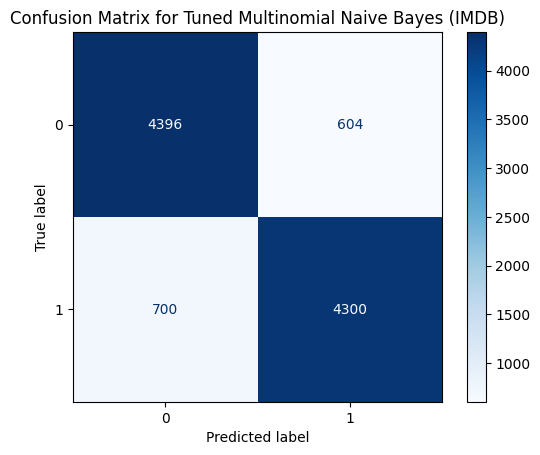

In [97]:
display_confusion_matrix(
    y_test,
    y_pred_mnb_tuned,
    title="Tuned Multinomial Naive Bayes (IMDB)"
)

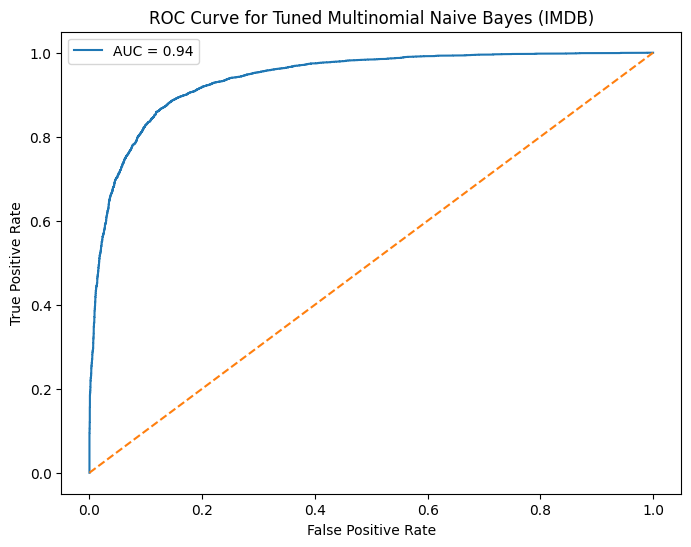

In [98]:
display_ROC(
    y_test,
    y_prob_mnb_tuned,
    title="Tuned Multinomial Naive Bayes (IMDB)"
)


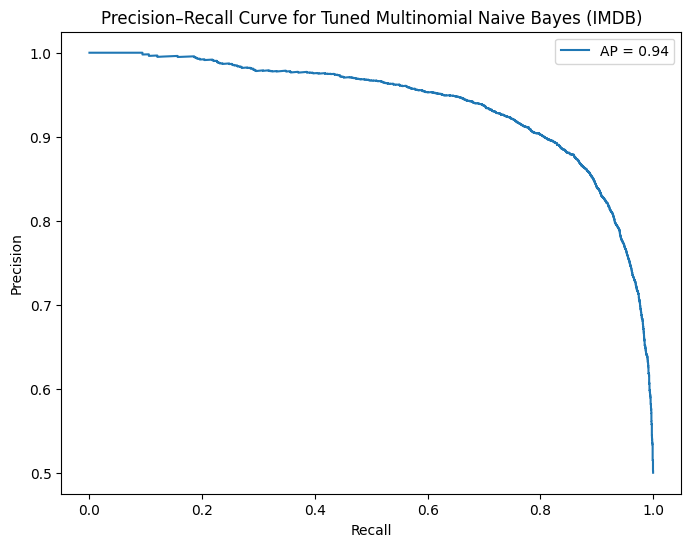

In [99]:
display_precision_recall_curve(
    y_test,
    y_prob_mnb_tuned,
    title="Tuned Multinomial Naive Bayes (IMDB)"
)


**Deep Learning Approach with BERT**

In [ ]:
!pip install transformers torch --quiet


In [ ]:
import torch
import torch.nn as nn
from torch.optim import AdamW
from transformers import BertTokenizer, BertForSequenceClassification
from torch.utils.data import DataLoader, TensorDataset

In [ ]:
df['text'] = df['review']
df['label'] = df['sentiment']


In [ ]:
train_dataframe, test_dataframe = train_test_split(
    df[['text', 'label']],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

In [ ]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning:


The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.



tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [ ]:
def preprocess_data(texts, labels, max_length=256):
    encoded = tokenizer.batch_encode_plus(
        texts,
        add_special_tokens=True,
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )
    return {
        'input_ids': encoded['input_ids'],
        'attention_mask': encoded['attention_mask'],
        'labels': torch.tensor(labels, dtype=torch.long)
    }


In [ ]:
train_data = preprocess_data(
    train_dataframe['text'].tolist(),
    train_dataframe['label'].tolist()
)

test_data = preprocess_data(
    test_dataframe['text'].tolist(),
    test_dataframe['label'].tolist()
)


In [ ]:
model = BertForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2
)


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
optimizer = AdamW(model.parameters(), lr=2e-5)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [ ]:
print(device)

cuda


In [ ]:
train_dataset = TensorDataset(
    train_data['input_ids'],
    train_data['attention_mask'],
    train_data['labels']
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)


In [ ]:
num_epochs = 3

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for batch in train_loader:
        input_ids, attention_mask, labels = [b.to(device) for b in batch]

        optimizer.zero_grad()

        outputs = model(
            input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {total_loss/len(train_loader):.4f}")


Epoch 1/3 - Loss: 0.2433
Epoch 2/3 - Loss: 0.1376
Epoch 3/3 - Loss: 0.0708


In [ ]:
torch.save(model.state_dict(), 'bert_sentiment_v1_model.pth')


In [ ]:
model.eval()



BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e

In [ ]:
import torch.nn.functional as F

In [ ]:
test_dataset = TensorDataset(test_data['input_ids'], test_data['attention_mask'], test_data['labels'])
test_loader = DataLoader(test_dataset, batch_size=32)

y_true_bert = []
y_pred_bert = []
y_prob_bert = []

with torch.no_grad():
    for batch in test_loader:
        input_ids, attention_mask, labels = [b.to(device) for b in batch]

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits
        probs = F.softmax(logits, dim=1)

        y_true_bert.extend(labels.cpu().numpy())
        y_pred_bert.extend(torch.argmax(probs, dim=1).cpu().numpy())
        y_prob_bert.extend(probs.cpu().numpy())

y_true_bert = np.array(y_true_bert)
y_pred_bert = np.array(y_pred_bert)
y_prob_bert = np.array(y_prob_bert)

# Accuracy & Report
accuracy = accuracy_score(y_true_bert, y_pred_bert)
print(f"Accuracy: {accuracy * 100:.2f}%")
print(classification_report(y_true_bert, y_pred_bert))

Accuracy: 92.71%
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      5000
           1       0.92      0.94      0.93      5000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



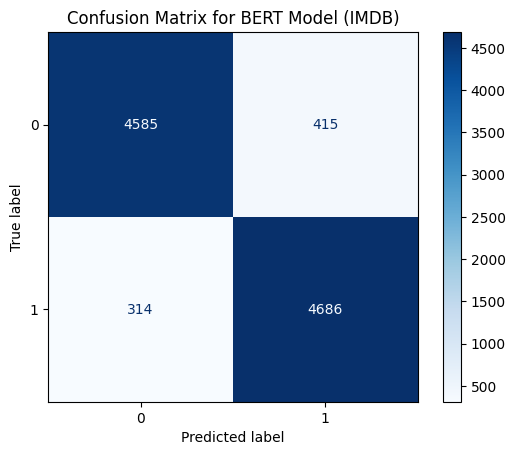

In [ ]:
# Confusion Matrix
display_confusion_matrix(
    y_true_bert,
    y_pred_bert,
    title="BERT Model (IMDB)"
)



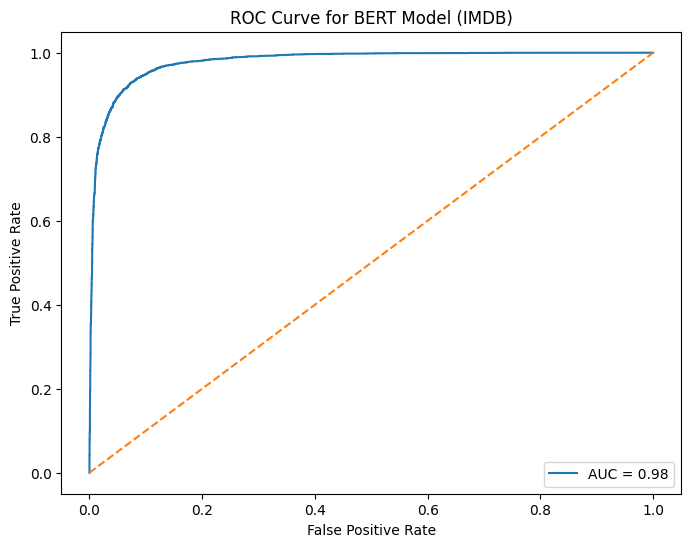

In [ ]:
# ROC Curve
display_ROC(
    y_true_bert,
    y_prob_bert,
    title="BERT Model (IMDB)"
)


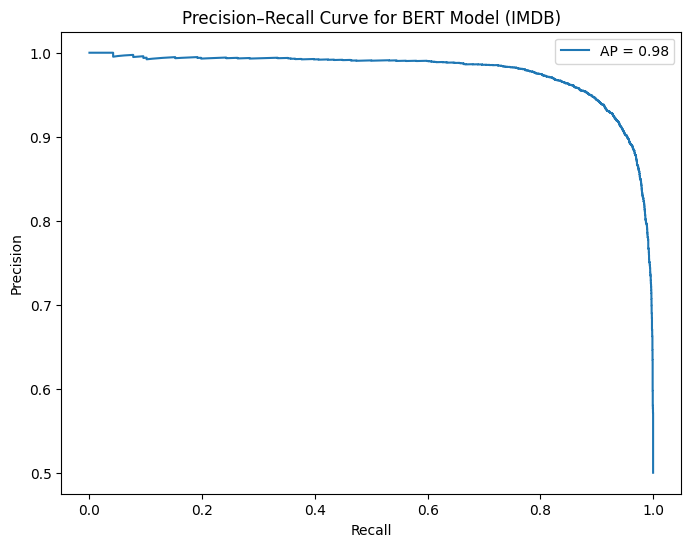

In [ ]:
# Precision Recall Curve
display_precision_recall_curve(
    y_true_bert,
    y_prob_bert,
    title="BERT Model (IMDB)"
)


In [ ]:
def predict_sentiment_bert(text):
    encoded = tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=256,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )

    input_ids = encoded['input_ids'].to(device)
    attention_mask = encoded['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        pred = torch.argmax(outputs.logits, dim=1).item()

    return "Positive" if pred == 1 else "Negative"


**PREDICTION OF REVIEWS USING BERT**

In [ ]:
print(predict_sentiment_bert("This movie was very enjoyable and well made."))
print(predict_sentiment_bert("The story was boring and the acting was poor."))

Positive
Negative


**COMPARISON OF PREDICTION REVIEWS USING MULTINOMIAL NAIVE BAYES AND BERT**

In [ ]:
test_reviews = [
    "I really wanted to like this movie, but despite the strong performances, it completely failed to keep me interested.",
    "The movie is not bad at all, but it is definitely not great either.",
    "If you enjoy watching paint dry, then this movie is perfect for you.",
    "Although the trailer made it look exciting, the actual movie was a disappointing and forgettable experience.",
    "I appreciate the effort, but the final result left a lot to be desired."

]

for i, text in enumerate(test_reviews, 1):
    print(f"Example {i}")
    print("Review:", text)
    print("Naive Bayes Prediction:", predict_sentiment_nb(text))
    print("BERT Prediction:", predict_sentiment_bert(text))
    print("-" * 80)


Example 1
Review: I really wanted to like this movie, but despite the strong performances, it completely failed to keep me interested.
Naive Bayes Prediction: Negative
BERT Prediction: Negative
--------------------------------------------------------------------------------
Example 2
Review: The movie is not bad at all, but it is definitely not great either.
Naive Bayes Prediction: Negative
BERT Prediction: Negative
--------------------------------------------------------------------------------
Example 3
Review: If you enjoy watching paint dry, then this movie is perfect for you.
Naive Bayes Prediction: Negative
BERT Prediction: Positive
--------------------------------------------------------------------------------
Example 4
Review: Although the trailer made it look exciting, the actual movie was a disappointing and forgettable experience.
Naive Bayes Prediction: Negative
BERT Prediction: Negative
--------------------------------------------------------------------------------
Examp

In [110]:
def labels(ax):
    for container in ax.containers:
        ax.bar_label(container, labels=[f"{v * 100:.2f}" for v in container.datavalues], padding=3)

def generate_performance_bar(df, title="Model Performance Comparison"):
    metrics = ['recall', 'precision', 'f1', 'accuracy']

    fig, axs = plt.subplots(4, 1, figsize=(14, 14))

    for i, metric in enumerate(metrics):
        df = df.sort_values(by=metric, ascending=False)
        ax = sns.barplot(x=metric, y="model name", hue="model name", legend=False, data=df, palette="Blues_d", ax=axs[i])
        ax.set_xlabel("")
        ax.set_title(metric.capitalize())
        labels(ax)
    plt.suptitle(title, y=1)
    plt.tight_layout()
    plt.show()

In [112]:
performance_df = pd.DataFrame({
    "model name": [
        "TF-IDF + MNB (1,1)",
        "CountVec + MNB (1,2)",
        "BERT"
    ],
    "accuracy": [0.8676, 0.8842, 0.9271],
    "precision": [0.87, 0.88, 0.93],
    "recall": [0.87, 0.88, 0.93],
    "f1": [0.87, 0.88, 0.93]
})


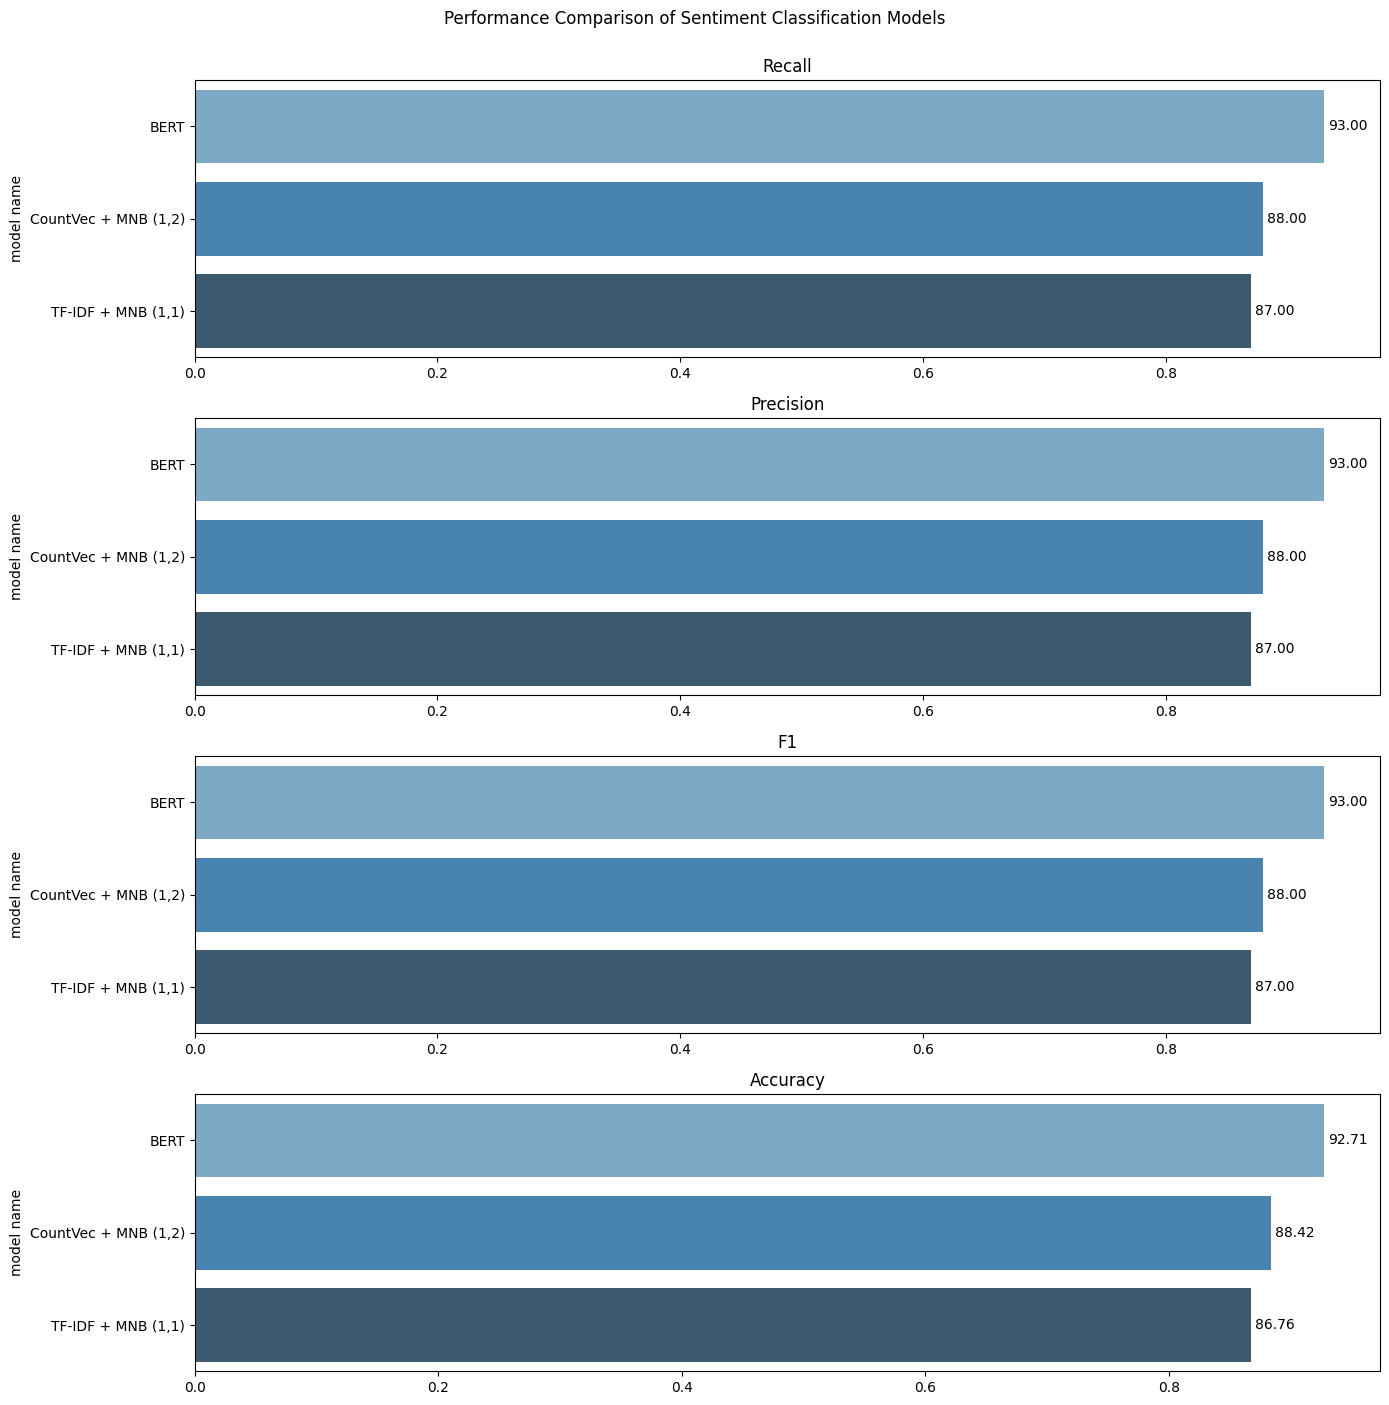

In [113]:
generate_performance_bar(
    performance_df,
    title="Performance Comparison of Sentiment Classification Models"
)
